<a href="https://colab.research.google.com/github/CodeShark-pro/Scheduler_Python/blob/main/Research_Mark2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Configuration & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings('ignore')
np.random.seed(42)

n_jobs = 25
POWER_IDLE = 2.0        # kW (High waste when waiting)
POWER_SLEEP = 0.01      # kW (Deep Sleep Saving)

# LOAD DATA
try:
    df_grid = pd.read_csv('hourlyLoadDataIndia.xlsx - Sheet1.csv')
    raw_load = df_grid['National Hourly Demand'].iloc[0:24].values
    l_min, l_max = np.min(raw_load), np.max(raw_load)
    carbon_intensity = 600 + ((raw_load - l_min) / (l_max - l_min)) * 320
except:
    hours = np.arange(0, 24)
    carbon_intensity = 600 + 200 * np.sin((hours - 6) * np.pi / 12)

green_threshold = np.percentile(carbon_intensity, 50)


Workload Generation

In [ ]:
n_small = int(n_jobs * 0.7)
n_large = n_jobs - n_small

tasks = pd.DataFrame({
    'Arrival_Hour': np.random.randint(0, 23, n_jobs),
    'Duration': np.random.exponential(scale=1.5, size=n_jobs).clip(0.5, 4.0),
    'Power_kW': np.concatenate([
        np.random.normal(0.5, 0.1, n_small), # Small Tasks
        np.random.normal(2.5, 0.5, n_large)  # Large Tasks
    ])
})

Simulation Engine

In [ ]:
def run_sim(mode, task_list, carbon_data):
    total_energy = 0
    total_carbon = 0
    grid_load_curve = np.zeros(24)

    for _, job in task_list.iterrows():
        arrival = int(job['Arrival_Hour'])
        duration = job['Duration']
        power = job['Power_kW']
        current = arrival

        if mode == 'Carbon-Aware':
            while carbon_data[current] > green_threshold and current < 23:
                current += 1

        job_energy = power * duration
        job_carbon = job_energy * carbon_data[current]

        total_energy += job_energy
        total_carbon += job_carbon

        end_hour = min(23, int(current + duration))
        grid_load_curve[current : end_hour + 1] += power

    # Sleep Mode Logic
    for h in range(24):
        if grid_load_curve[h] == 0:
            if mode == 'Standard':
                total_energy += POWER_IDLE
                grid_load_curve[h] += POWER_IDLE
            else:
                total_energy += POWER_SLEEP
                grid_load_curve[h] += POWER_SLEEP

    return total_energy, total_carbon, grid_load_curve

# Run Simulations
e_std, c_std, load_std = run_sim('Standard', tasks, carbon_intensity)
e_our, c_our, load_our = run_sim('Carbon-Aware', tasks, carbon_intensity)

# Calculate Savings
c_savings = ((c_std - c_our) / c_std) * 100
e_savings = ((e_std - e_our) / e_std) * 100

Visualization

--- RESEARCH RESULTS ---
Carbon Savings: 8.64%
Energy Savings: 13.97%


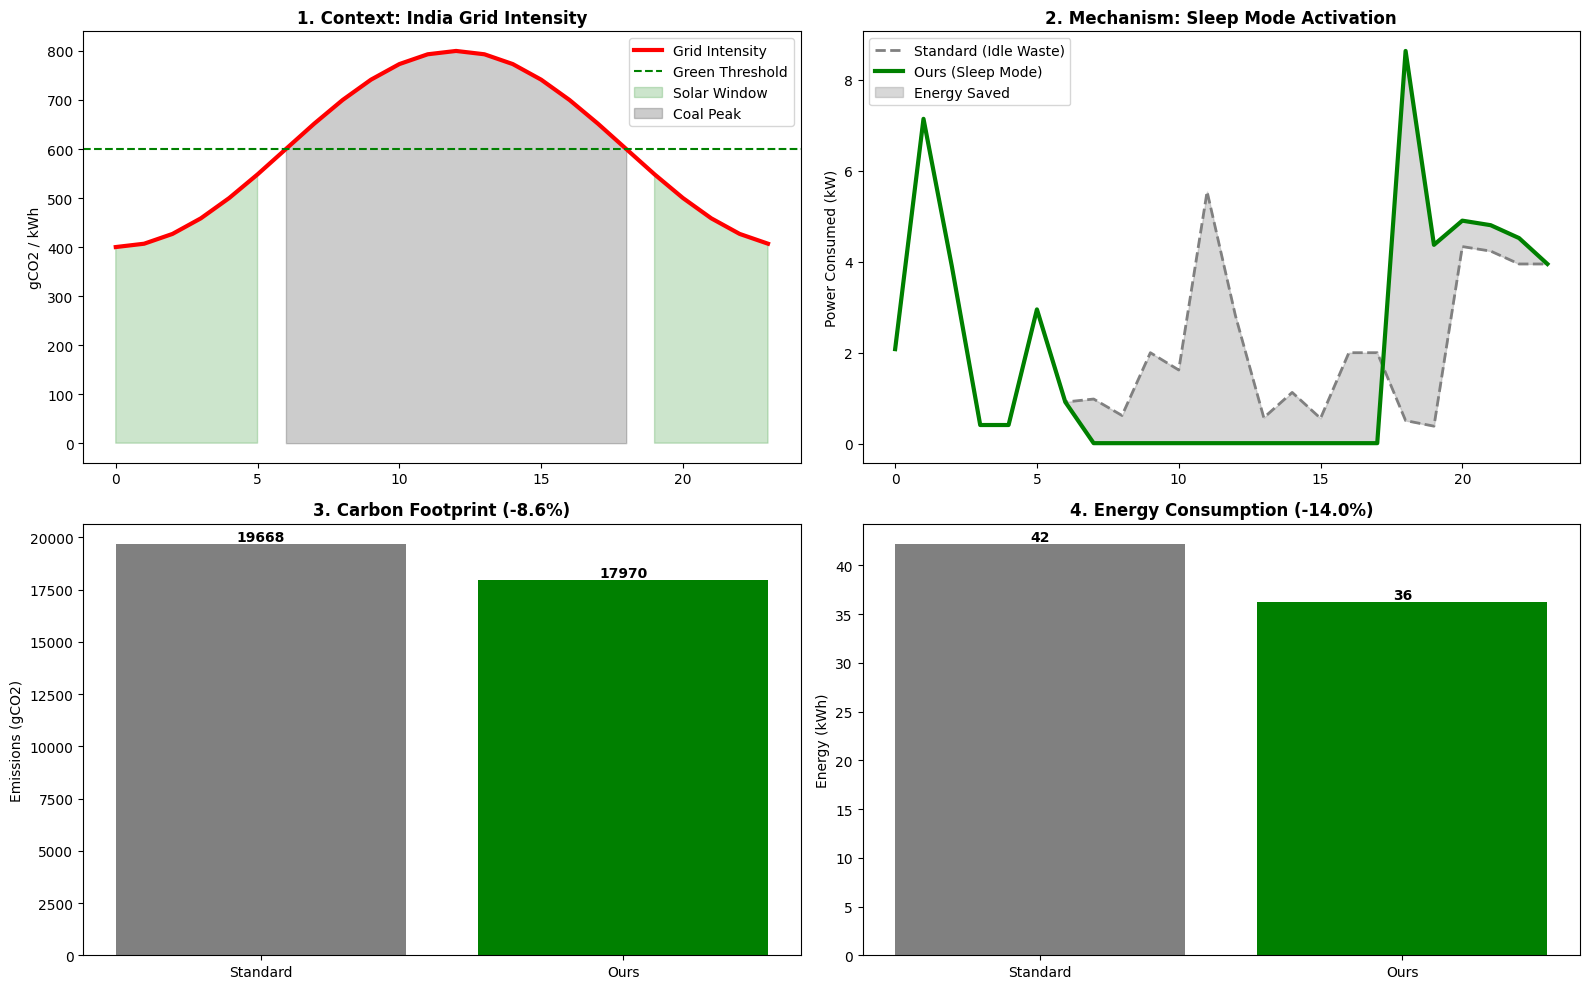

In [ ]:

print(f"--- RESEARCH RESULTS ---")
print(f"Carbon Savings: {c_savings:.2f}%")
print(f"Energy Savings: {e_savings:.2f}%")

plt.figure(figsize=(16, 10))

# Graph 1: Context
plt.subplot(2, 2, 1)
plt.plot(carbon_intensity, 'r-', linewidth=3, label='Grid Intensity')
plt.axhline(y=green_threshold, color='g', linestyle='--', label='Green Threshold')
plt.fill_between(range(24), 0, carbon_intensity, where=(carbon_intensity < green_threshold), color='green', alpha=0.2, label='Solar Window')
plt.fill_between(range(24), 0, carbon_intensity, where=(carbon_intensity >= green_threshold), color='black', alpha=0.2, label='Coal Peak')
plt.title("1. Context: India Grid Intensity", fontsize=12, fontweight='bold')
plt.ylabel("gCO2 / kWh")
plt.legend()

# Graph 2: Mechanism
plt.subplot(2, 2, 2)
plt.plot(load_std, 'gray', linestyle='--', linewidth=2, label='Standard (Idle Waste)')
plt.plot(load_our, 'green', linewidth=3, label='Ours (Sleep Mode)')
plt.fill_between(range(24), load_std, load_our, color='gray', alpha=0.3, label='Energy Saved')
plt.title("2. Mechanism: Sleep Mode Activation", fontsize=12, fontweight='bold')
plt.ylabel("Power Consumed (kW)")
plt.legend()

# Graph 3: Carbon Results
plt.subplot(2, 2, 3)
bars1 = plt.bar(['Standard', 'Ours'], [c_std, c_our], color=['gray', 'green'])
plt.title(f"3. Carbon Footprint (-{c_savings:.1f}%)", fontsize=12, fontweight='bold')
plt.ylabel("Emissions (gCO2)")
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold')

# Graph 4: Energy Results
plt.subplot(2, 2, 4)
bars2 = plt.bar(['Standard', 'Ours'], [e_std, e_our], color=['gray', 'green'])
plt.title(f"4. Energy Consumption (-{e_savings:.1f}%)", fontsize=12, fontweight='bold')
plt.ylabel("Energy (kWh)")
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()